# Greeks under the Black-Scholes model

In this notebook, we compute and visualize the main analytical Greeks
of European options under the Black-Scholes model.

The objective is to understand how option prices react to changes in:
- the stock price
- volatility
- time to maturity

## What are Greeks?

Greeks measure the sensitivity of an option price to changes in the main
model parameters.

Main Greeks studied in this notebook:

- Delta: sensitivity to the stock price
- Gamma: sensitivity of Delta to the stock price
- Vega: sensitivity to volatility
- Theta: sensitivity to time decay

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import pandas as pd

In [2]:
# Black-Scholes auxiliary quantities

def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

## Analytical formulas
Price for a European call option:
**C = S N(d1) − K e^(−rT) N(d2)**

Price for a European put option:
**P = K e^(−rT) N(-d2) − S N(-d1)**


Under the Black-Scholes model, the main Greeks are given by closed-form
formulas.

For a European call option:
- Delta = N(d1)
- Gamma = N'(d1) / (S σ √T)
- Vega = S N'(d1) √T
- Theta = - S N'(d1) σ / (2√T) - r K e^(-rT) N(d2)

For a European put option:
- Delta = N(d1) - 1
- Gamma = same as for the call
- Vega = same as for the call
- Theta = - S N'(d1) σ / (2√T) + r K e^(-rT) N(-d2)

In [3]:
#Greeks

# Delta: sensitivity to the stock price
def delta_call(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma))

def delta_put(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma)) - 1

# Gamma: sensitivity of Delta to the stock price
def gamma(S, K, T, r, sigma):
    d1_value = d1(S, K, T, r, sigma)
    return norm.pdf(d1_value) / (S * sigma * np.sqrt(T))

# Vega: sensitivity to volatility
def vega(S, K, T, r, sigma):
    d1_value = d1(S, K, T, r, sigma)
    return S * norm.pdf(d1_value) * np.sqrt(T)

# Theta: sensitivity to time decay
def theta_call(S, K, T, r, sigma):
    d1_value = d1(S, K, T, r, sigma)
    d2_value = d2(S, K, T, r, sigma)
    term1 = - (S * norm.pdf(d1_value) * sigma) / (2 * np.sqrt(T))
    term2 = - r * K * np.exp(-r * T) * norm.cdf(d2_value)   
    return term1 + term2

def theta_put(S, K, T, r, sigma):
    d1_value = d1(S, K, T, r, sigma)
    d2_value = d2(S, K, T, r, sigma)  
    term1 = - (S * norm.pdf(d1_value) * sigma) / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r * T) * norm.cdf(-d2_value)
    return term1 + term2

## Choice of parameters

We use an at-the-money (ATM) configuration, meaning that the strike price
is equal (or very close) to the current stock price.

This corresponds to an ATM option :

Around the ATM region, the option is in a situation where it is uncertain
whether it will finish in-the-money or out-of-the-money.

Because of this uncertainty:
- small changes in the stock price have a large impact → high Delta sensitivity
- Delta changes quickly → high Gamma
- changes in volatility strongly affect the price → high Vega

In contrast:
- if the option is deep in-the-money (e.g. K = 120 when S = 165),
  the outcome is almost certain → Greeks are less informative
- if the option is deep out-of-the-money (e.g. K = 200),
  the option is unlikely to be exercised → low sensitivities

Therefore, ATM options provide the most informative view of how Greeks behave.

In [4]:
# Base parameters - Airbus market inputs

airbus = yf.download("AIR.PA", period="2y", auto_adjust=False)
airbus = airbus[["Adj Close"]].dropna()

airbus["log_return"] = np.log(airbus["Adj Close"] / airbus["Adj Close"].shift(1))
airbus["vol_20d"] = airbus["log_return"].rolling(20).std() * np.sqrt(252)
airbus = airbus.dropna()

S0 = float(airbus["Adj Close"].iloc[-1])
K = S0                  # ATM strike based on Airbus
r = 0.02
sigma = float(airbus["vol_20d"].iloc[-1])
T = 30 / 252

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_300/1395899111.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(airbus["Adj Close"].iloc[-1])


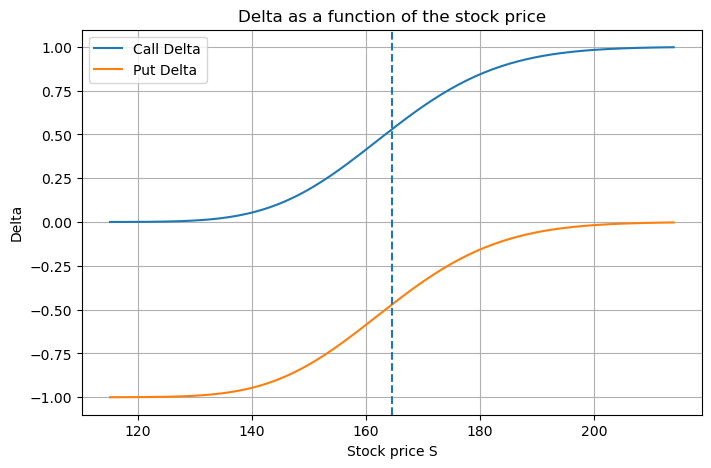

In [5]:
# Delta as a function of the stock price

S_values = np.linspace(0.7 * S0, 1.3 * S0, 200)

delta_call_values = [delta_call(S, K, T, r, sigma) for S in S_values]
delta_put_values = [delta_put(S, K, T, r, sigma) for S in S_values]

plt.figure(figsize=(8,5))
plt.plot(S_values, delta_call_values, label="Call Delta")
plt.plot(S_values, delta_put_values, label="Put Delta")
plt.axvline(K, linestyle="--")
plt.title("Delta as a function of the stock price")
plt.xlabel("Stock price S")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Delta

Delta measures the sensitivity of the option price to a small change
in the stock price.

For call options, Delta increases from 0 to 1 as the option moves from
out-of-the-money to in-the-money.

For put options, Delta ranges from -1 to 0.

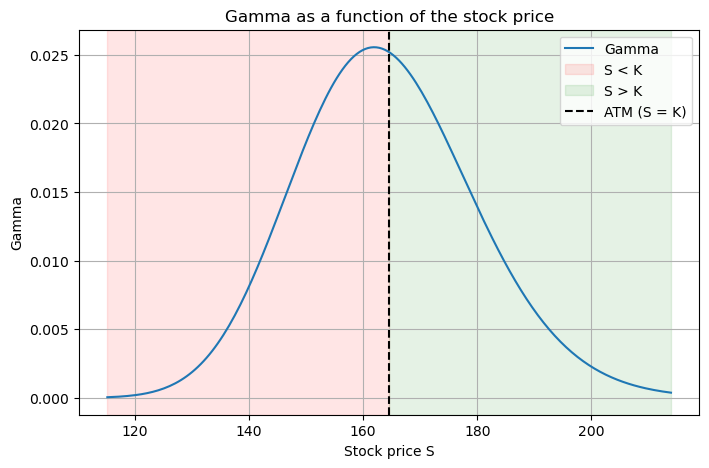

In [6]:
# Gamma as a function of the stock price

gamma_values = [gamma(S, K, T, r, sigma) for S in S_values]

plt.figure(figsize=(8,5))

# Courbe Gamma
plt.plot(S_values, gamma_values, label="Gamma")

# --- Zones ---
xmin = min(S_values)
xmax = max(S_values)

# Zone S < K
plt.axvspan(xmin, K, alpha=0.1, color="red", label="S < K")

# Zone S > K
plt.axvspan(K, xmax, alpha=0.1, color="green", label="S > K")

# Ligne ATM
plt.axvline(K, linestyle="--", color="black", label="ATM (S = K)")

# --- Mise en forme ---
plt.title("Gamma as a function of the stock price")
plt.xlabel("Stock price S")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Gamma

Gamma measures the sensitivity of Delta to changes in the stock price.

It is highest around the at-the-money region, where Delta changes most
rapidly.

Gamma is the same for European calls and puts under Black-Scholes.

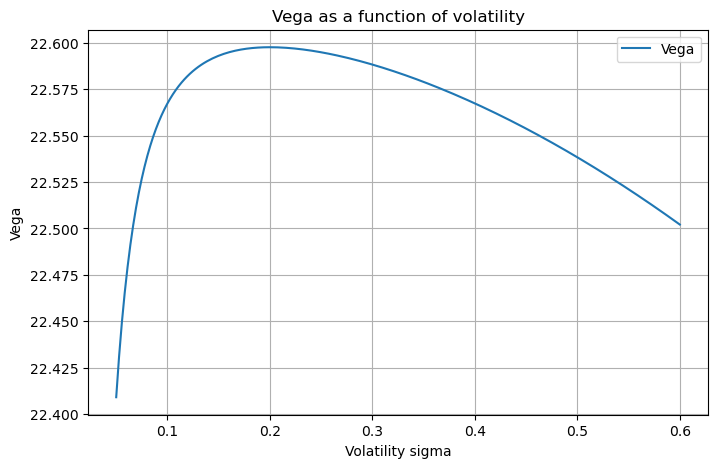

In [7]:
# Vega as a function of volatility

sigma_values = np.linspace(0.05, 0.60, 200)

vega_values = [vega(S0, K, T, r, sig) for sig in sigma_values]

plt.figure(figsize=(8,5))
plt.plot(sigma_values, vega_values, label="Vega")
plt.title("Vega as a function of volatility")
plt.xlabel("Volatility sigma")
plt.ylabel("Vega")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Vega

Vega measures the sensitivity of the option price to changes in volatility.

A higher volatility increases the uncertainty about the terminal stock price,
which generally increases the value of both call and put options.

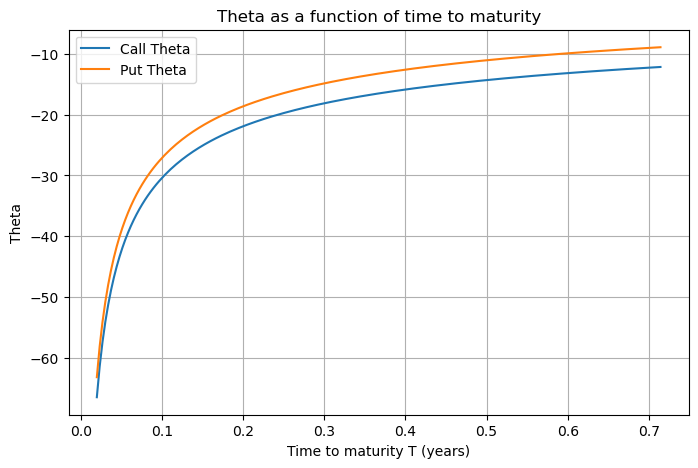

In [8]:
# Theta as a function of time to maturity

T_values = np.linspace(5/252, 180/252, 200)

theta_call_values = [theta_call(S0, K, t, r, sigma) for t in T_values]
theta_put_values = [theta_put(S0, K, t, r, sigma) for t in T_values]

plt.figure(figsize=(8,5))
plt.plot(T_values, theta_call_values, label="Call Theta")
plt.plot(T_values, theta_put_values, label="Put Theta")
plt.title("Theta as a function of time to maturity")
plt.xlabel("Time to maturity T (years)")
plt.ylabel("Theta")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Theta

Theta measures the sensitivity of the option price to the passage of time.

For many options, Theta is negative: as time passes, the option loses time
value.

This effect is particularly important close to maturity.